# Deep Learning Assignment 1
## Logan Justin Gunawan (s4096363)

## Part A: Building the Classifier

### The Task:

This task is a multiclass classification problem using a series of 5 images to classify a string of human gestures as one of 13 gestures. These gesture classifications will then be used for RedKite's line of drones delivering time-critical medical supplies to hard to reach areas. Our main constraint is the performance constraint of the drone's hardware, which is only capable for one modest 2-D CNN classifier. Another important constraint is the limited size of our dataset, containing only ~1000 Instances, or ~5000 Images.

In [12]:
# Imports
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset
import torch.optim as optim
import matplotlib.pyplot as plt
import os
from pathlib import Path
import random
from IPython.display import clear_output

### Exploring the Data:

The dataset is given to us under the folder schema of COMMAND/SUBJECT_ID/INSTANCE_ID/, (e.g AllClear/S1/Instance1) the order of the images in the sequence is given via the naming scheme of the file, e.g ...instance1_1.png, ...instance1_2.png.

The following code creates a DataFrame object where every Image is converted into a 3D Array of shape: (Height x Width x Channels) in our case (512 x 512 x 3). The Dataframe records rows as one instance, with columns ID, Image[1-5] and Label where Label is the Command that the instance represents.

In [13]:
DATA_PATH = Path.cwd() / "data_resized"
COMMANDS = ["AllClear", "HaveCommand", "Hover",
            "Land", "LandingDirection", "MoveAhead",
            "MoveDownward", "MoveToLeft", "MoveToRight",
            "MoveUpward", "NotClear", "SlowDown",
            "WaveOff"]

# Load the Data
Data = pd.DataFrame(columns=["ID", "Image1", "Image2", "Image3", "Image4", "Image5", "Label"])

def LoadData():
    global Data

    Rows = []

    for Command in COMMANDS:
        FolderPath = DATA_PATH / Command                        # FolderPath <- 'data_resized/AllClear'
        for Folder in os.listdir(FolderPath):
            if Folder == ".DS_Store":
                continue

            FilePath = FolderPath / Folder                # FilePath <- 'data_resized/AllClear/S1'
            for Instance in os.listdir(FilePath):
                if Instance == ".DS_Store":
                    continue

                InstancePath = FilePath / Instance        # InstancePath <- 'data_resized/AllClear/S1/Instance1'
                ImageArray = []
                
                
                for Image in os.listdir(InstancePath):
                    if Image == ".DS_Store":
                        continue

                    ImagePath = InstancePath / Image      # ImagePath <- 'data_resized/AllClear/S1/Instance1/Image1.jpg'

                    ImageArray.append(ImagePath)
                    
                Rows.append(["_".join([Command, Folder, Instance]), 
                                        ImageArray[0], 
                                        ImageArray[1], 
                                        ImageArray[2], 
                                        ImageArray[3], 
                                        ImageArray[4], 
                                        Command])

    Data = pd.DataFrame(Rows, columns = ["ID", "Image1", "Image2", "Image3", "Image4", "Image5", "Label"])

LoadData()

I'd also like to see the class breakdown for Label. Creating a Pie Chart below, I can see some imbalance such as Land taking up ~11% of the Dataset whereas LandingDirection only takes up ~4.5%. However, this is not as concerning as it can be. I will just need to remember to stratify the data later when splitting it to ensure that the model has an equal distribution for training and validating.

([<matplotlib.patches.Wedge at 0x1ad2e0439d0>,
 [Text(1.0635668227537534, 0.28075899547029, 'AllClear'),
  Text(0.7909714328157853, 0.7644371736574196, 'HaveCommand'),
  Text(0.3324616656086802, 1.0485557881680414, 'Hover'),
  Text(-0.32311689446052677, 1.0514730013244207, 'Land'),
  Text(-0.7909714085169954, 0.7644371987996402, 'LandingDirection'),
  Text(-1.0398401304758238, 0.35879312012916587, 'MoveAhead'),
  Text(-1.0947331165575813, -0.107514666497763, 'MoveDownward'),
  Text(-0.9566807846377313, -0.5429197696759024, 'MoveToLeft'),
  Text(-0.5186265636489341, -0.9700651975396799, 'MoveToRight'),
  Text(-0.027734760327780442, -1.0996503003544176, 'MoveUpward'),
  Text(0.4423364424310276, -1.007143719484693, 'NotClear'),
  Text(0.8914502638946198, -0.6444504845232198, 'SlowDown'),
  Text(1.0831938925831421, -0.19154892604914495, 'WaveOff')],
 [Text(0.5801273578656836, 0.15314127025652177, '8.2%'),
  Text(0.4314389633540647, 0.41696573108586515, '8.0%'),
  Text(0.18134272669564372, 

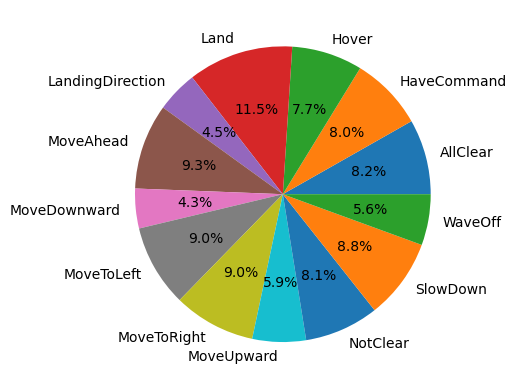

In [14]:
ValCounts = Data["Label"].value_counts()

plt.pie([ValCounts[Col].item() for Col in COMMANDS],
        autopct = '%1.1f%%', 
        labels = COMMANDS)

Next, I create a simple helper function to showcase a collection of the Images in each instance below. This will allow me to easily view the collection of Images associated with any action.

In [15]:
# ---------------------------------------------------------------------------------------
# -----------Code Generated by GitHub Copilot, See End of Notebook for prompt------------
# ---------------------------------------------------------------------------------------

def display_command_instance_images(commands=None, folder="S1", instance="Instance1"):
    if commands is None:
        commands = COMMANDS
    elif isinstance(commands, str):
        commands = [commands]

    invalid_commands = [cmd for cmd in commands if cmd not in COMMANDS]
    if invalid_commands:
        raise ValueError(f"Unsupported command(s): {invalid_commands}")

    rows = len(commands)
    cols = 5

    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 4 * rows))

    if rows == 1:
        axes = np.array([axes]).reshape(1, -1)
    elif cols == 1:
        axes = np.array(axes).reshape(-1, 1)
    else:
        axes = np.array(axes)

    for row, command in enumerate(commands):
        instance_dir = DATA_PATH / command / folder / instance
        if not instance_dir.exists():
            raise FileNotFoundError(f"Could not find: {instance_dir}")

        image_files = sorted([
            p for p in instance_dir.iterdir()
            if p.is_file() and p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp", ".gif"}
        ])

        if not image_files:
            raise FileNotFoundError(f"No images found in: {instance_dir}")

        for col in range(cols):
            ax = axes[row, col]
            image_file = image_files[col] if col < len(image_files) else None

            if image_file is None:
                ax.axis("off")
                ax.set_title(f"{command}\nImage {col + 1}\nmissing")
                continue

            ax.imshow(plt.imread(image_file))
            ax.axis("off")
            ax.set_title(f"{command}\nImage {col + 1}")

    plt.tight_layout()
    plt.show()

What I learnt from doing this exploration is the patterns associated with each Command. What this means is that for a drone operator to want to signal a specific Command, they will move to act a certain string of actions in order for the drone to recognize it as a single command. The easiest example of this can be shown below: for the command Hover, the operator will stand in a T formation and remain in position. 

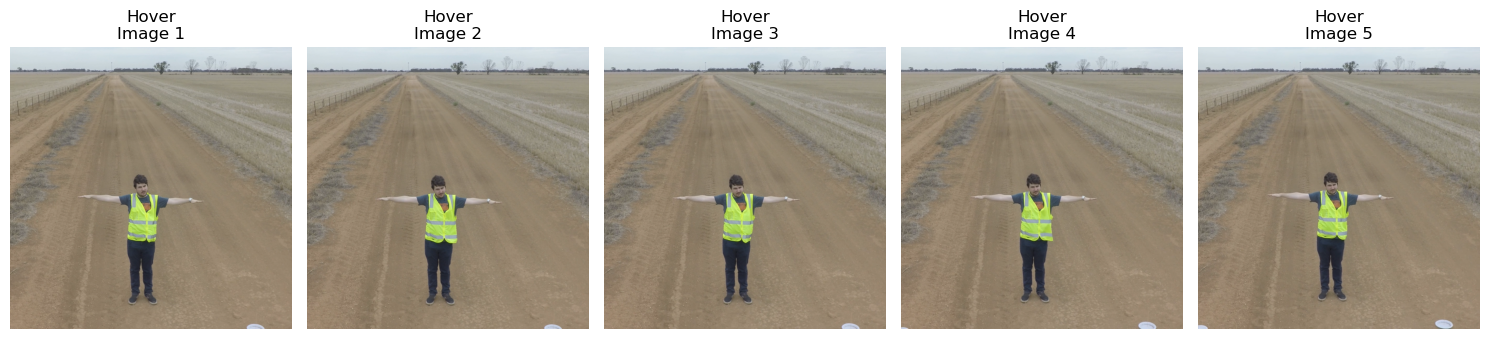

In [16]:
display_command_instance_images(commands=["Hover"], folder="S1", instance="Instance1")

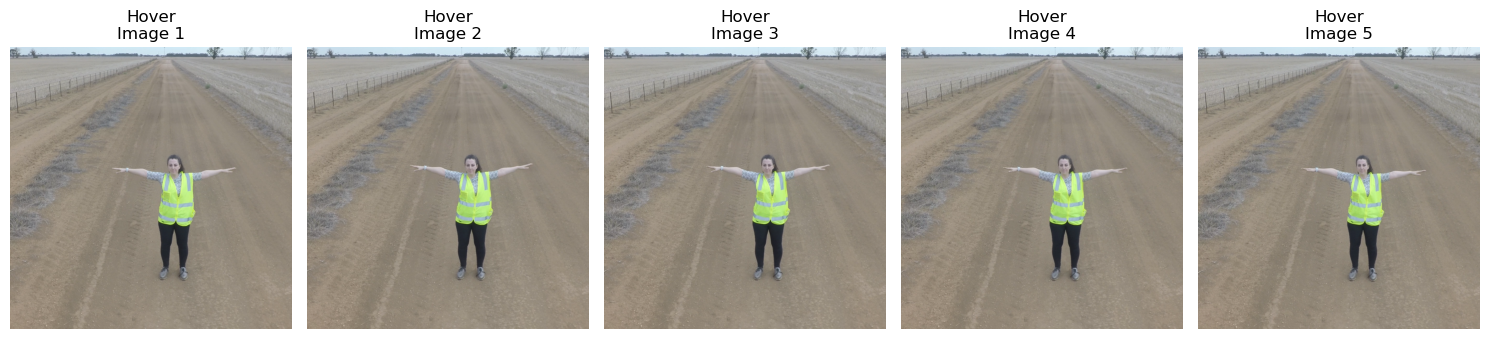

In [17]:
display_command_instance_images(commands=["Hover"], folder="S4", instance="Instance1")

Another example can be Landing Direction where the operator will stand facing their left and put their arms towards their head, then point to the left and repeat that motion.

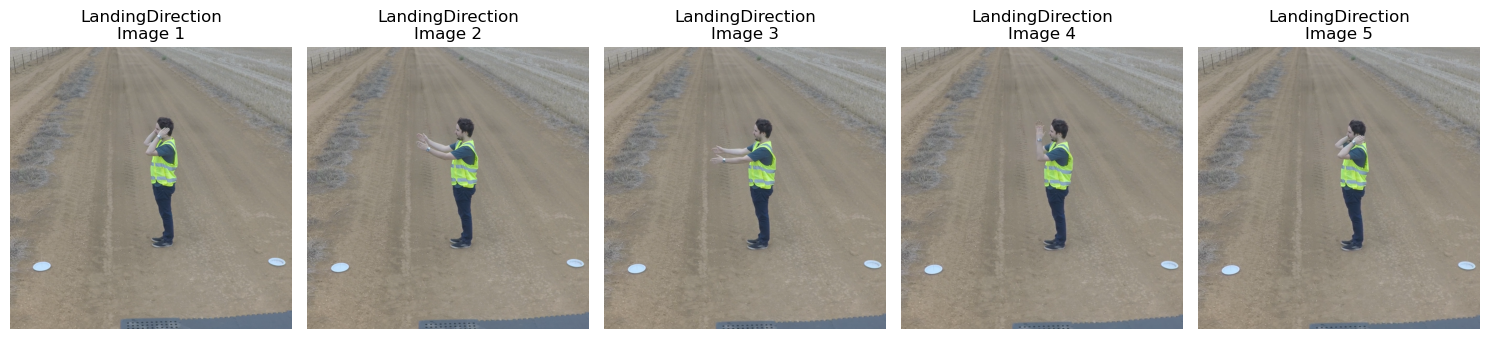

In [18]:
display_command_instance_images(commands=["LandingDirection"], folder="S1", instance="Instance1")

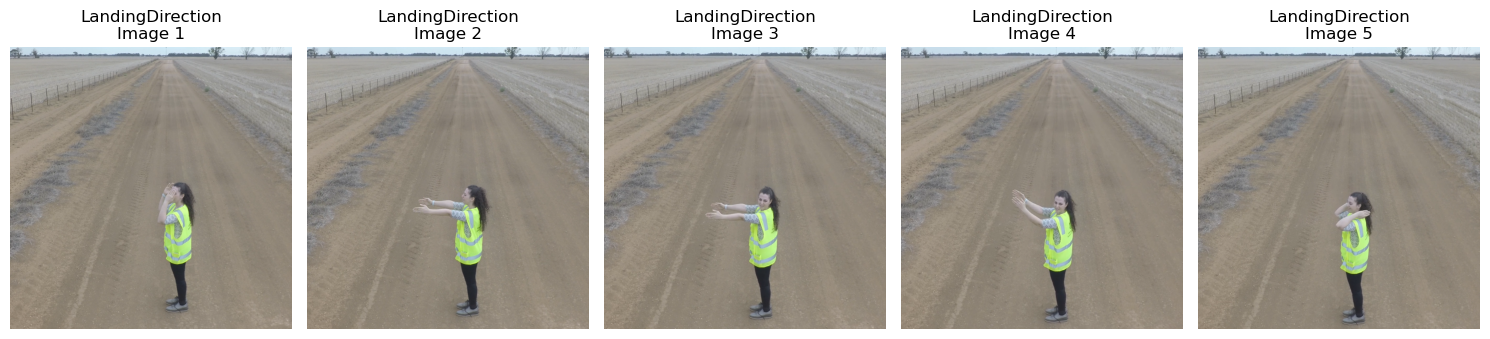

In [19]:
display_command_instance_images(commands=["LandingDirection"], folder="S4", instance="Instance1")

Another thing I noticed was the lack of similar features in many of the images. Whether it be different subjects, different physical environments, different camera angles and positioning, the only constants would be that the human subject will wear a bright hi-vis jacket and use their arms to create gestures. 

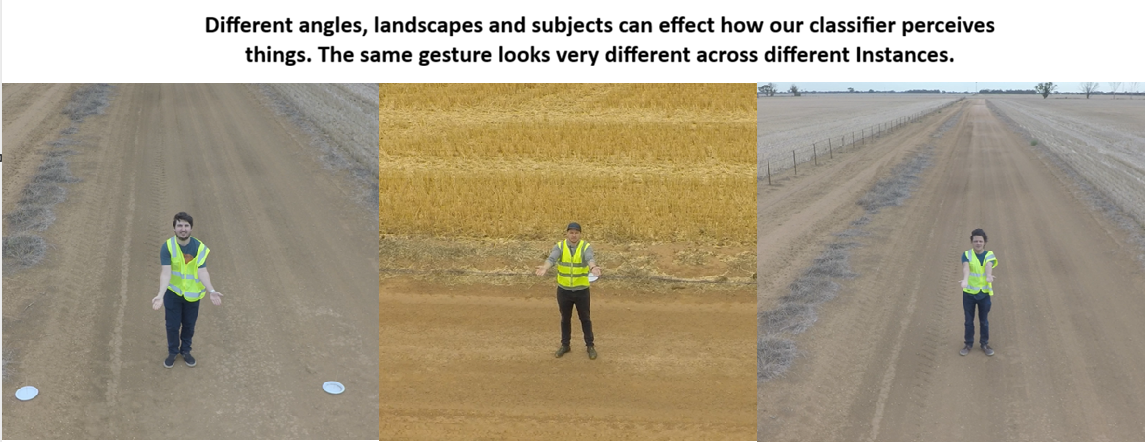

## Building the Models

### The Idea: 

My proposal for the final model revolves around the idea of Feature Extraction on each frame of a row, extracting only the most important features from each Image before passing it through several Dense layers in order to classify a string of Images as being one command. The important feature that I am referring to in each Image will be the "Gesture" represented in each image, because the resulting Action is based on a string of Gestures it may be wise to create a Gesture Recognition Model (GRM) which is will be a CNN classifier as stepping stone to the final Action Model (A.M).

The only hurdle to this task is that creating the GRM will require labelled data for each Gesture, which is not present in the current dataset. To get over this, I decided to label the data myself. 

### Intro to Gestures:

Based on my own observation of the data, I have created myself a set of possible Gestures for each Image to classify as which can be seen in this image below. 

What Gestures I added to the gesture set were based on several of the following considerations.

#### Is this Gesture distinct enough to classify as a its own Gesture?

From a human eye, can I see that there is a very specific Gesture that the subject is trying to portray? From my eyes, I can very distinctly tell that this subject is trying to communicate a T-Pose, becauses if I compare it with any other Gesture, I can very easily tell that these sets of Images are trying to communicate the same distinct pose. 

#### How significant will this Gesture effect the A.M?

What is the significance of this Gesture? One example of this came from an earlier Gesture Set which did not have the Gestures: ThumbsUp and ThumbsDown. These two images below would both be classified as just being LeftNeutral. However, it is important for the model to understand the difference between ThumbsDown and ThumbsUp in these images, because of the commands: AllClear and NotClear which share almost exactly the same Gestures with the exception of ThumbsUp in AllClear and ThumbsDown in NotClear. Not having these models will horribly effect the A.M.

#### How large will the final Gesture Set be?

The Gesture Set should not be too large, we want a set of only the most Significant Gestures to look out for. Insignificant gestures like NeutralHandsOnHip will bloat the Gesture Set and make it more difficult for the GRM to make correct predictions, leading to worse A.M performances.

## Methodology

First I decide on a 60-40 data split, where 60% of the data will go to training and validating the GRM, while 40% of the data will go to training and validating the A.M. What is important here is that I stratify the data based on Action so that I will have an equal distribution of Action strings when training both models.

60% of the data allocated to the GRM will be labelled while the other 40% will not. This roughly equates to ~3100 individual images that will require labelling.

In [20]:
GestureData, RestData = train_test_split(Data,
                                         test_size=0.4,
                                         train_size=0.6,
                                         random_state=67,
                                         stratify=Data["Label"])

GestureData.reset_index(inplace=True)
RestData.reset_index(inplace=True)

In [21]:
SingleImages = pd.DataFrame({
    "Image" : GestureData[["Image1", "Image2", "Image3", "Image4", "Image5"]].to_numpy().flatten()
})

In [22]:
GestureMap = {
    "n" : "Neutral",
    "f" : "Front",
    "p" : "Point",
    "lu" : "LeftUp",
    "ln" : "LeftNeutral",
    "c" : "Cross",
    "uc" : "UpCross",
    "t" : "TPose",
    "tlu" : "TLeftUp",
    "tlo" : "TLeftOut",
    "tlm" : "TLeftMe",
    "tro" : "TRightOut",
    "tru" : "TRightUp",
    "trm" : "TRightMe",
    "flm" : "FrontLeftMe",
    "flu" : "FrontLeftUp",
    "fln" : "FrontLeftNeutral",
    "fm" : "FrontMe",
    "hu" : "HandsUp",
    "luu" : "LeftUpUp",
    "tu" : "ThumbsUp",
    "td" : "ThumbsDown"
}

### Labelling

Below I have created a simple cell code which will display to the user an Image and prompt them to assign it to one of the 13 possible labels. The code will continue until all 3100 Images are labelled. I also save the already labelled images as a Dictionary where the key corresponds to the Index of the image in the dataset and its Value is its assigned label. The code will serialize this Map as a pickle file which acts as a save so that I can do this labelling process across multiple sessions. In total it took ~5 hours.


Right now the code is commented out so that it does not run and obstruct the flow of code in this notebook. To try out the code, rename the existing file LabelMap.pkl to something else, uncomment it then run it. Type 'exit' to stop labelling. (Warning: If you do attempt this, replace the new LabelMap.pkl with the old one so that the GRM will learn properly.)

In [23]:

LabelledDataset = pd.DataFrame(columns=["Image", "Gesture"])
Map = {}

if os.path.isfile("LabelMap.pkl"):
    with open("LabelMap.pkl", 'rb') as file:
        Map = pickle.load(file)

print(Map)
Label = ""
Counter = len(Map)
Break = False

while Counter < 5 * len(GestureData) and not Break:
    Row = Counter // 5
    Col = Counter % 5
    
    print(f"Row: {Row}")
    print(f"Col: {Col}")
    
    Image = plt.imread(GestureData.loc[Row][f"Image{Col+1}"])
    clear_output(wait=True)
    plt.imshow(Image)
    plt.title(f"{GestureData.loc[Row]["ID"]} Image: {Col+1} Counter: {Counter}")
    plt.show(block=False)
    plt.pause(0.1)
    
    Label = input("Label: ").lower().strip()
    while Label not in GestureMap:
        if Label == "exit":
            Break = True
            break
        Label = input("Invalid Gesture Try Again: ").lower()
    
    if Break:
        break

    Map[Counter] = GestureMap[Label]
    #LabelledDataset.loc[Counter] = [Image, GestureMap[Label]]
    
    Counter += 1

print(f"Start from Counter: {Counter}")
with open("LabelMap.pkl", 'wb') as file:
    pickle.dump(Map, file)


{0: 'Cross', 1: 'Cross', 2: 'Cross', 3: 'Cross', 4: 'Cross', 5: 'Neutral', 6: 'Point', 7: 'LeftUpUp', 8: 'Point', 9: 'Neutral', 10: 'TPose', 11: 'TRightUp', 12: 'TRightMe', 13: 'TPose', 14: 'TPose', 15: 'TPose', 16: 'HandsUp', 17: 'UpCross', 18: 'HandsUp', 19: 'HandsUp', 20: 'TPose', 21: 'TPose', 22: 'TPose', 23: 'TPose', 24: 'TPose', 25: 'TPose', 26: 'TRightUp', 27: 'TRightUp', 28: 'TPose', 29: 'TPose', 30: 'TPose', 31: 'TPose', 32: 'TLeftUp', 33: 'TLeftOut', 34: 'TPose', 35: 'Cross', 36: 'Cross', 37: 'Cross', 38: 'Cross', 39: 'Cross', 40: 'Neutral', 41: 'FrontMe', 42: 'FrontMe', 43: 'Neutral', 44: 'Neutral', 45: 'TLeftOut', 46: 'TLeftUp', 47: 'TLeftMe', 48: 'TLeftUp', 49: 'TLeftOut', 50: 'TPose', 51: 'HandsUp', 52: 'UpCross', 53: 'HandsUp', 54: 'TPose', 55: 'TPose', 56: 'TPose', 57: 'TPose', 58: 'TPose', 59: 'TPose', 60: 'Neutral', 61: 'Point', 62: 'LeftUpUp', 63: 'Point', 64: 'Neutral', 65: 'TPose', 66: 'TLeftMe', 67: 'TLeftMe', 68: 'TLeftOut', 69: 'TLeftOut', 70: 'TPose', 71: 'Hand

In [24]:
Map = {}
if os.path.isfile("LabelMap.pkl"):
    with open("LabelMap.pkl", 'rb') as file:
        Map = pickle.load(file)

In [25]:
Values = [Value for key, Value in Map.items()]

SingleImages["Gesture"] = Values

In [26]:
SingleImages["Gesture"].value_counts()

Gesture
TPose               700
Neutral             620
Cross               365
Front               207
HandsUp             159
ThumbsDown          147
ThumbsUp            140
FrontMe             140
TRightUp             69
LeftUpUp             67
TLeftUp              63
TRightMe             61
TLeftMe              61
FrontLeftMe          60
TLeftOut             52
Point                50
FrontLeftNeutral     48
UpCross              40
FrontLeftUp          39
TRightOut            35
LeftNeutral          34
LeftUp               18
Name: count, dtype: int64

One thing that I am concerned about is the class imbalance of the Gestures. There are many gestures which have a below triple digit value count, such as LeftUp which has 18, FrontLeftUp which has 39, etc. While Gestures like TPose and Neutral dominate the dataset with >600 values each. There is not much that can be done due to the limited size of the dataset. However, this does mean that our model will likely overfit towards the class dominant Gestures and will be less certain when dealing with the minority Gestures. 

## The Gesture Recognition Model

For my GRM, I know that I will have an input (for one image) of size (3, 512, 512) representing Channels, Height and Width of an Image,  and an eventual output of 22 which represents the Confidence for each Gesture. I know that I will want several layers of 2D Convolutions as well as Average Pooling Layers to create learnable filters as well as downsample the input size. And I know that I will want these learnable filters to eventually be flattened and passed through at least 1 Dense Layer to create the final output.

As it currently stands the biggest concern is the incredibly large input size (without any Convolution / Pooling layers a flattened image will have a size of 786,432). I will need to balance the number of Convolutional Layers as well as the parameters of kernel_size and stride to ensure efficient but not too aggressive downsampling. 

Below is what I have determined to be an apt enough architecture for the GRM. Important design decisions include: 
- multiple ReLU() activation layers to introduce non-linearity to the classifier. 
- Kernel size of 3 and stride of 2 for the Convolutional Layers and Kernel Size of 3 and stride of 3 for the Pooling layers, with 3 total layers as a good balance of efficient but not too aggressive downsampling. 
- One hidden layer after concatenation before the final layer, although the ratio from the input size of 6400 to output size of 128 seems extreme, adding multiple hidden layers seems to only decrease performance. 
- I also did not include a SoftMax layer to the final output of the model, one reason for this is that pytorch's CrossEntropyCriterion expects raw Logits, however, I have another reason which will be explained later when building A.M.

In [27]:
class GestureRecognitionModel(nn.Module):
    def __init__(self):
        super(GestureRecognitionModel, self).__init__()
        self.CNN = nn.Sequential(
            nn.Conv2d(in_channels = 3,
                      out_channels = 16,
                      kernel_size = 3,
                      stride = 2,
                      padding = 1,
                      padding_mode = 'zeros'),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size = 3,
                         stride = 3,
                         padding = 1),
            
            nn.Conv2d(in_channels = 16,
                      out_channels = 32,
                      kernel_size = 3,
                      stride = 1,
                      padding = 1,
                      padding_mode = 'zeros'),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size = 3,
                         stride = 3,
                         padding = 1),

            nn.Conv2d(in_channels = 32,
                      out_channels = 64,
                      kernel_size = 3,
                      stride = 1,
                      padding = 1,
                      padding_mode = 'zeros'),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size = 3,
                         stride = 3,
                         padding = 1),
        )

        self.Classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = 6400,
                      out_features = 128),
            nn.ReLU(),
            nn.Linear(in_features = 128,
                      out_features = 22)
        )
    
    def forward(self, input):
        Conv = self.CNN(input)
        Output = self.Classifier(Conv)
        
        return Output

In [28]:
class GestureDataset(Dataset):
    def __init__(self, df):
        self.Data = df
    
    def __len__(self):
        return len(self.Data)

    def __getitem__(self, index):
        Row = self.Data.iloc[index]
        Image = plt.imread(Row["Image"])
        Image = torch.tensor(Image, dtype=torch.float32)
        Image = Image.permute(2, 0, 1)
        Gesture = torch.tensor(Row["Gesture"], dtype=torch.long)
        return Image, Gesture

In [29]:
Image_Train, Image_Val = train_test_split(SingleImages,
                                         test_size=0.4,
                                         train_size=0.6,
                                         random_state=67,
                                         stratify=SingleImages["Gesture"])

GestureEncoder = LabelEncoder().fit(Image_Train["Gesture"])
Image_Train["Gesture"] = GestureEncoder.transform(Image_Train["Gesture"])
Image_Val["Gesture"] = GestureEncoder.transform(Image_Val["Gesture"])

In [30]:
Image_Train = GestureDataset(Image_Train)
Image_Val = GestureDataset(Image_Val)

In [37]:
BatchSize = 32

Data_Loader = DataLoader(Image_Train, 
                         batch_size = BatchSize, 
                         shuffle = True)

Val_Loader = DataLoader(Image_Val,
                        batch_size = 16,
                        shuffle = True)

Device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

GRM = GestureRecognitionModel().to(Device)

ClassCounts = Image_Train.Data["Gesture"].value_counts().sort_index()

ClassWeights = len(Image_Train) / (
    len(ClassCounts) * ClassCounts
)

ClassWeights = torch.tensor(
    ClassWeights.to_numpy(),
    dtype=torch.float32
)

In [38]:
print(ClassWeights)

tensor([0.3954, 0.6983, 2.4053, 2.9859, 3.7648, 1.0308, 0.9020, 4.3295, 7.8719,
        2.1648, 0.2328, 2.8864, 2.3403, 2.7933, 2.2787, 0.2062, 2.3403, 4.1234,
        2.1120, 0.9840, 1.0308, 3.6080])


In [42]:
def Train(Model, 
          Optimizer, 
          Data_Loader,
          Val_Loader,
          ClassWeights,
          SavePath, 
          NumEpochs = 100, 
          Patience = 5):
    
    CrossEntropyCriterion = nn.CrossEntropyLoss(
        weight = ClassWeights
    )

    LossTracker = []
    AccuracyTracker = []
    ValLossTracker = []
    ValAccuracyTracker = []

    LowestLoss = 10000
    Counter = 0

    for Epoch in range(NumEpochs):
        Model.train()
        
        TrainingLoss = 0
        ValTotal = 0
        ValCorrect = 0
        
        TrainCorrect = 0
        TrainTotal = 0
        
        for BatchX, BatchY in Data_Loader:
            Optimizer.zero_grad()
            
            Logits = Model(BatchX)
            
            Predictions = Logits.argmax(dim=1)
            
            TrainCorrect += (Predictions == BatchY).sum().item()
            TrainTotal += BatchY.size(0)
            
            Loss = CrossEntropyCriterion(Logits, BatchY)
            
            Loss.backward()
            
            Optimizer.step()
            
            TrainingLoss += Loss.item()
        
        Model.eval()
        
        ValLoss = 0
        ValCorrect = 0
        ValTotal = 0
        
        with torch.no_grad():
            for ValX, ValY in Val_Loader:
                ValLogits = Model(ValX)
                ValLoss += CrossEntropyCriterion(ValLogits, ValY).item()
                ValPredictions = ValLogits.argmax(dim=1)
                ValCorrect += (ValPredictions == ValY).sum().item()
                ValTotal += ValY.size(0)
        
        ValLoss /= len(Val_Loader)
        ValMean = ValCorrect / ValTotal
        MeanLoss = TrainingLoss / len(Data_Loader)
        
        LossTracker.append(MeanLoss)
        AccuracyTracker.append(TrainCorrect / TrainTotal)
        ValLossTracker.append(ValLoss)
        ValAccuracyTracker.append(ValMean)
        
        print(f"Epoch: {Epoch} / {NumEpochs}")
        print(f"Mean Loss: {MeanLoss : .4f}")
        print(f"Mean Accuracy: {TrainCorrect / TrainTotal : .4f}")
        print(f"Mean Validation Accuracy: {ValMean : .4f}")
        print(f"Val Loss: {ValLoss : .4f}")
        
        if ValLoss < LowestLoss:
            Counter = 0
            LowestLoss = ValLoss
            
            torch.save(Model.state_dict(), SavePath)
        else:
            Counter += 1
            
            if Counter >= Patience:
                break
    
    fig, ax = plt.subplots(2,2)
    ax[0, 0].plot(LossTracker)
    ax[0, 0].set_title("Training Loss")

    ax[0, 1].plot(ValLossTracker)
    ax[0, 1].set_title("Validation Loss")

    ax[1, 0].plot(AccuracyTracker)
    ax[1, 0].set_title("Training Accuracy")

    ax[1, 1].plot(ValAccuracyTracker)
    ax[1, 1].set_title("Validation Accuracy")

    plt.tight_layout()
    plt.show()

In [ ]:
Adam = optim.Adam(GRM.parameters(), lr = 5e-3)

Train(GRM, 
      Adam, 
      Data_Loader, 
      Val_Loader, 
      ClassWeights,
      "BestGRM3.pth",
      100, 
      10)

In [ ]:
GRM = GestureRecognitionModel()
GRM.load_state_dict(torch.load("BestGRM.pth"))
GRM.eval()

GestureRecognitionModel(
  (CNN): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=3, stride=3, padding=1)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=3, stride=3, padding=1)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AvgPool2d(kernel_size=3, stride=3, padding=1)
  )
  (Classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6400, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=23, bias=True)
  )
)

Text(0.2, -0.025, 'Probability of Actual:  0.036')

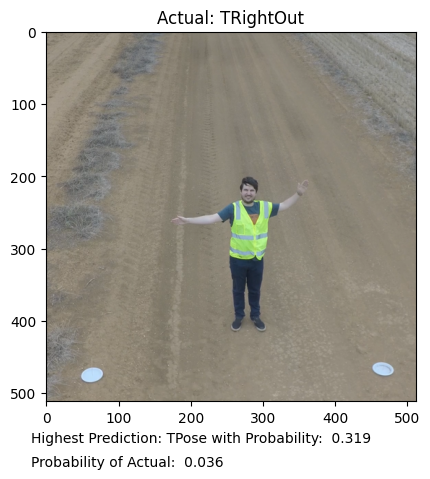

In [ ]:
RandomNum = random.randint(0, len(Image_Val) - 1)
RandomImage, Label = Image_Val[RandomNum]

ValLogits = GRM(RandomImage)
Label = int(Label.item())
Predicted = int(torch.argmax(ValLogits, dim=1).item())

plt.imshow(RandomImage.permute(1, 2, 0))
plt.axis("off")
plt.title(f"Actual: {GestureEncoder.inverse_transform([Label])[0]}")
plt.figtext(0.2, 0.025, f"Highest Prediction: {GestureEncoder.inverse_transform([Predicted])[0]} with Probability: {ValLogits[RandomNum][Predicted] : .3f}")
plt.figtext(0.2, -0.025, f"Probability of Actual: {ValLogits[RandomNum][Label] : .3f}")

### The Action Model

In [ ]:
class ActionModel(nn.Module):
    def __init__(self, GRM):
        super(ActionModel, self).__init__()
        self.GRM = GRM

        self.Decider = nn.Sequential(
            nn.Linear(in_features = 115,
                      out_features = 64),
            nn.ReLU(),
            nn.Linear(in_features = 64,
                      out_features = 13)
        )
        
    def forward(self, input):
        self.GRM.eval()
        
        GestureOutputs = []
        
        with torch.no_grad():
            for i in range(5):
                GestureOutputs.append(self.GRM(input[: , i]))
        
        Combined = torch.concat(GestureOutputs, dim=1)
        Output = self.Decider(Combined)
        
        return Output

In [ ]:
class ActionDataset(Dataset):
    def __init__(self, df):
        self.Data = df
        
    def __len__(self):
        return len(self.Data)

    def __getitem__(self, index):
        Row = self.Data.iloc[index]
        Images = []
        
        for i in range(5):
            Image = plt.imread(Row[f"Image{i+1}"])
            Image = torch.tensor(Image, dtype = torch.float32)
            Image = Image.permute(2, 0, 1)
            Images.append(Image)
        
        Images = torch.stack(Images)
        
        Action = torch.tensor(Row["Label"], dtype=torch.long)
        
        return Images, Action

In [ ]:
Action_Train, Action_Val = train_test_split(RestData,
                                            test_size = 0.2,
                                            train_size = 0.8,
                                            random_state = 67,
                                            stratify = RestData["Label"])

ActionEncoder = LabelEncoder().fit(Action_Train["Label"])
Action_Train["Label"] = ActionEncoder.transform(Action_Train["Label"])
Action_Val["Label"] = ActionEncoder.transform(Action_Val["Label"])

In [ ]:
Action_Train = ActionDataset(Action_Train)
Action_Val = ActionDataset(Action_Val)

In [ ]:
BatchSize = 16

Data_Loader2 = DataLoader(Action_Train,
                          batch_size = BatchSize,
                          shuffle = True)

Val_Loader2 = DataLoader(Action_Val,
                         batch_size = 8,
                         shuffle = True)

Device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

GRM = GestureRecognitionModel()
GRM.load_state_dict(torch.load("BestGRM.pth"))
AM = ActionModel(GRM)

Epoch: 0 / 100
Mean Loss:  0.4210
Mean Accuracy:  0.8584
Mean Validation Accuracy:  0.6588
Val Loss:  1.0103
Epoch: 1 / 100
Mean Loss:  0.3817
Mean Accuracy:  0.8850
Mean Validation Accuracy:  0.6588
Val Loss:  0.9690
Epoch: 2 / 100
Mean Loss:  0.3184
Mean Accuracy:  0.8938
Mean Validation Accuracy:  0.7059
Val Loss:  0.9317
Epoch: 3 / 100
Mean Loss:  0.3118
Mean Accuracy:  0.8791
Mean Validation Accuracy:  0.6118
Val Loss:  1.0050
Epoch: 4 / 100
Mean Loss:  0.3251
Mean Accuracy:  0.8732
Mean Validation Accuracy:  0.6824
Val Loss:  0.9184
Epoch: 5 / 100
Mean Loss:  0.2599
Mean Accuracy:  0.9351
Mean Validation Accuracy:  0.7059
Val Loss:  0.9241
Epoch: 6 / 100
Mean Loss:  0.2376
Mean Accuracy:  0.9263
Mean Validation Accuracy:  0.6588
Val Loss:  0.9737
Epoch: 7 / 100
Mean Loss:  0.2399
Mean Accuracy:  0.9381
Mean Validation Accuracy:  0.6824
Val Loss:  0.9475
Epoch: 8 / 100
Mean Loss:  0.2521
Mean Accuracy:  0.9292
Mean Validation Accuracy:  0.7176
Val Loss:  1.0456
Epoch: 9 / 100
Mean

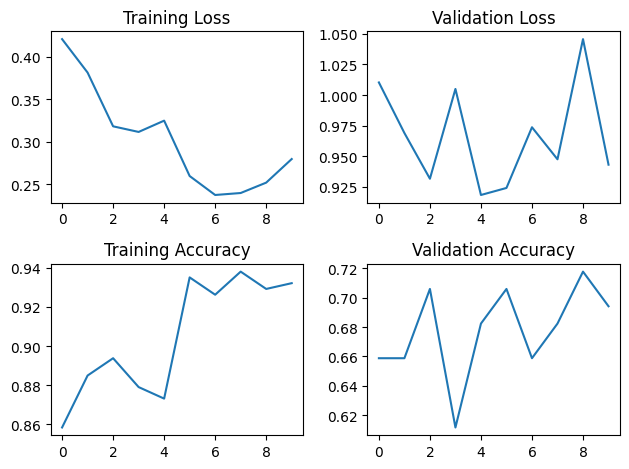

In [ ]:
Eve = optim.Adam(AM.parameters(), lr = 1e-3)

Train(AM,
      Eve,
      Data_Loader2,
      Val_Loader2,
      "BestAM2.pth",
      100,
      5)

In [ ]:
AM = ActionModel(GRM)
AM.load_state_dict(torch.load("BestAM.pth"))
AM.eval()

NameError: name 'ActionModel' is not defined

In [ ]:
with torch.no_grad():
    ValLogits = AM(Action_Val_Tensors)
    ValLoss = CrossEntropyCriterion(ValLogits, Label_Val_Tensor).item()
    ValLogits = torch.softmax(ValLogits, dim=1)
    ValPredictions = ValLogits.argmax(dim=1)
    ValCorrect = (ValPredictions == Label_Val_Tensor).sum().item()
    ValTotal = Label_Val_Tensor.size(0)
    
    print(f"Final Model Accuracy: {ValCorrect / ValTotal : .4f}")

Final Model Accuracy:  0.6824


Text(0.3, 0.025, 'Probability of Actual:  0.742')

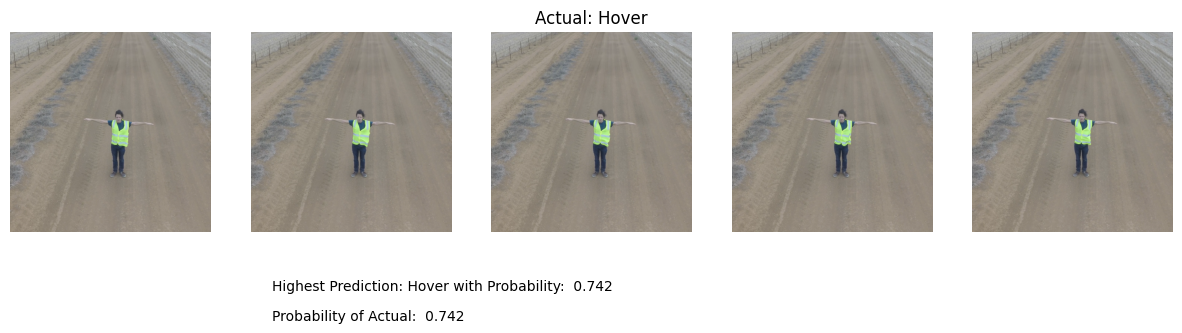

In [ ]:
RandomNum = random.randint(0, Action_Val_Tensors.size(0) - 1)
RandomImages = [im.permute(1,2,0) for im in Action_Val_Tensors[RandomNum]]

Predicted = ValPredictions[RandomNum]
Actual = Label_Val_Tensor[RandomNum].item()

fig, ax = plt.subplots(1, 5, figsize=(15, 4))

for i in range(5):
    ax[i].imshow(RandomImages[i])
    ax[i].axis("off")
    
ax[2].set_title(f"Actual: {ActionEncoder.inverse_transform([Actual])[0]}")
fig.text(0.3, 0.1, f"Highest Prediction: {ActionEncoder.inverse_transform([Predicted])[0]} with Probability: {ValLogits[RandomNum][Predicted] : .3f}")
fig.text(0.3, 0.025, f"Probability of Actual: {ValLogits[RandomNum][Actual] : .3f}")

### AI Usage:

AI-Model: GitHub Co-Pilot Auto

Summary: Create a helper function to display a row of Images associated with a command (which is passed as a parameter). 

Returned: display_command_images() Function.

Prompt: "Create a function that will display the five images associated with one instance from one of the 13 commands which will be passed in as a parameter."

Text Output:

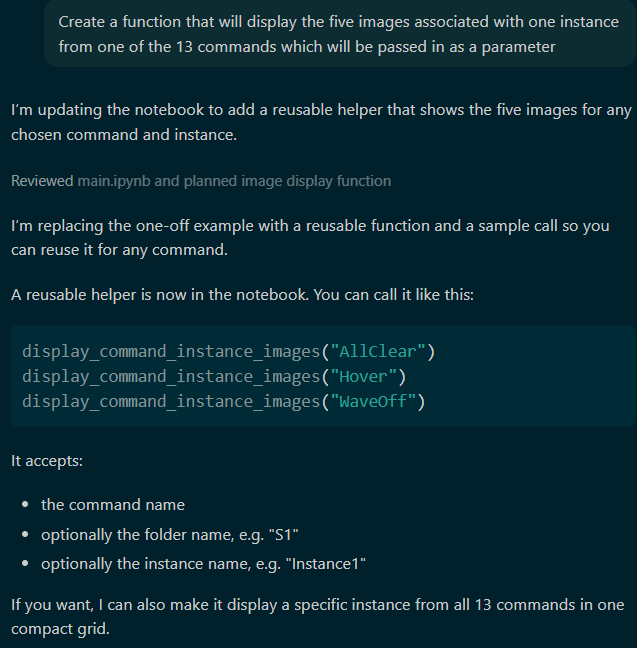 

Code Output: 

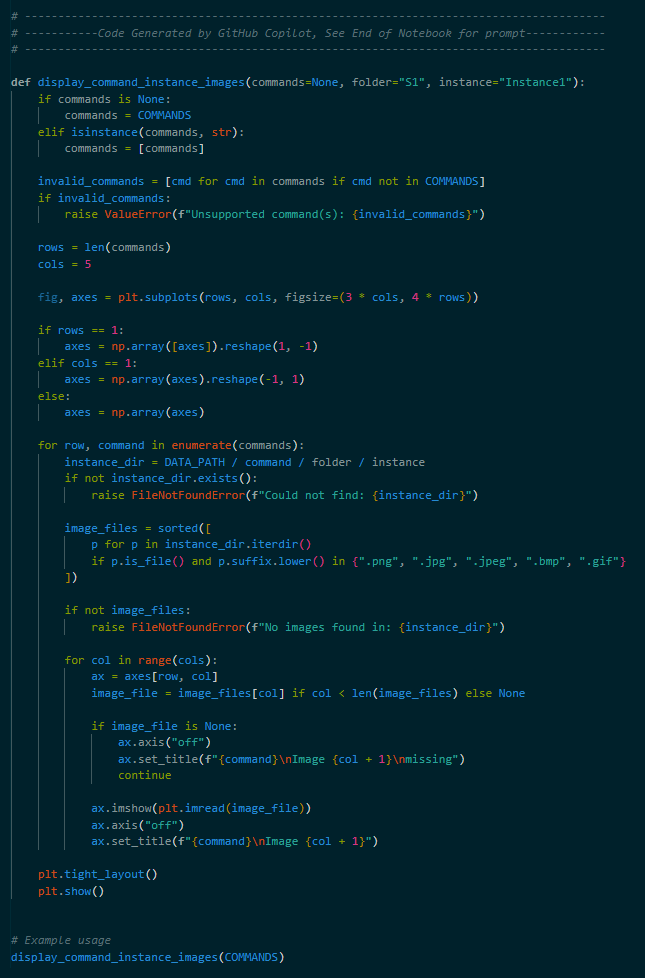